In [128]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from scipy.stats import ttest_rel

In [130]:
df = pd.read_csv(r'C:\Users\Hena\Desktop\Pilot Survey Data\Final Food Survey Data.csv', encoding='ISO-8859-1')

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   No.                        317 non-null    int64  
 1   Food Service Sectors       317 non-null    object 
 2   Northing                   317 non-null    object 
 3   Easting                    317 non-null    object 
 4   Number of years            317 non-null    int64  
 5   Number of Employees        317 non-null    int64  
 6   Gross floor Area  (m2)     317 non-null    int64  
 7   Number of Tables           317 non-null    int64  
 8   Catering Services          317 non-null    object 
 9   Quantity of FP (ton/Year)  317 non-null    int64  
 10  Quantity of FA (ton/Year)  317 non-null    float64
dtypes: float64(1), int64(6), object(4)
memory usage: 27.4+ KB


In [134]:
df.head()

,No.,Food Service Sectors,Northing,Easting,Number of years,Number of Employees,Gross floor Area (m2),Number of Tables,Catering Services,Quantity of FP (ton/Year),Quantity of FA (ton/Year)
0,1,The Corporate Cocktail bar and food court,"9° 0' 8.842"" N","38° 45' 46.730"" E",29,38,6500,48,Yes,2912,2392.0
1,2,Bole Wing bar and Restaurant,"8° 59' 47.825"" N","38° 46' 22.468"" E",26,34,6000,43,Yes,2600,2158.0
2,3,Antica Bar and Restaurant,"8° 59' 47.248"" N","38° 46' 45.210"" E",30,39,6600,50,No,3016,2496.0
3,4,Black Street Bar and Restaurant,"9° 0' 2.789"" N","38° 45' 46.671"" E",34,45,7500,58,Yes,3328,2912.0
4,5,Variety Restaurant and Lounge,"8° 59' 47.091"" N","38° 47' 15.537"" E",28,37,6400,48,No,3016,2392.0


In [136]:
df.describe()

,No.,Number of years,Number of Employees,Gross floor Area (m2),Number of Tables,Quantity of FP (ton/Year),Quantity of FA (ton/Year)
count,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000
mean,159.000000,13.460568,15.864353,2478.309148,22.003155,1313.533123,1103.417035
std,91.654242,8.370903,13.134548,2472.705361,16.310767,981.815296,827.110653
min,1.000000,3.000000,1.000000,48.000000,1.000000,52.000000,31.200000
25%,80.000000,7.000000,4.000000,260.000000,7.000000,416.000000,351.000000
50%,159.000000,11.000000,12.000000,1100.000000,19.000000,1144.000000,936.000000
75%,238.000000,18.000000,27.000000,4800.000000,35.000000,2132.000000,1768.000000
max,317.000000,38.000000,47.000000,7800.000000,60.000000,3432.000000,3016.000000


In [138]:
df = df.drop(columns=df.select_dtypes(include='object').columns)
df = df.drop(columns=['No.', 'Number of Tables'])

In [140]:
df.isnull().sum()

Number of years              0
Number of Employees          0
Gross floor Area  (m2)       0
Quantity of FP (ton/Year)    0
Quantity of FA (ton/Year)    0
dtype: int64

In [142]:
df.duplicated().sum()

0

In [144]:
df[df.duplicated(keep=False)]

,Number of years,Number of Employees,Gross floor Area (m2),Quantity of FP (ton/Year),Quantity of FA (ton/Year)


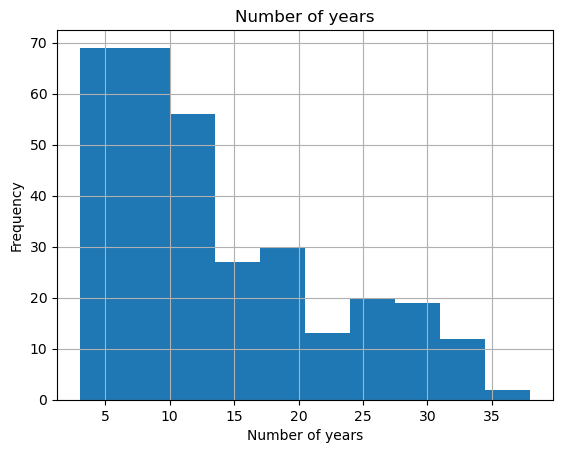

In [146]:
col = df.columns[0]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Food Report/first_column_hist.png')

plt.show()

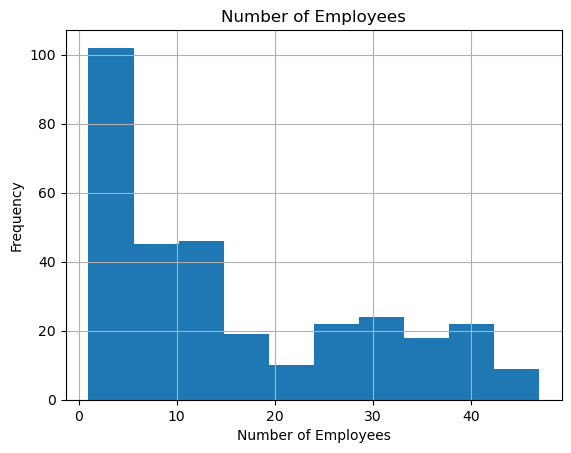

In [147]:
col = df.columns[1]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Food Report/second_column_hist.png')

plt.show()

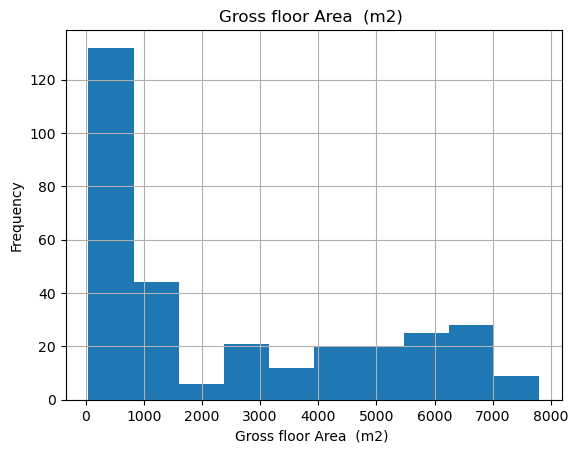

In [148]:
col = df.columns[2]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Food Report/third_column_hist.png')

plt.show()

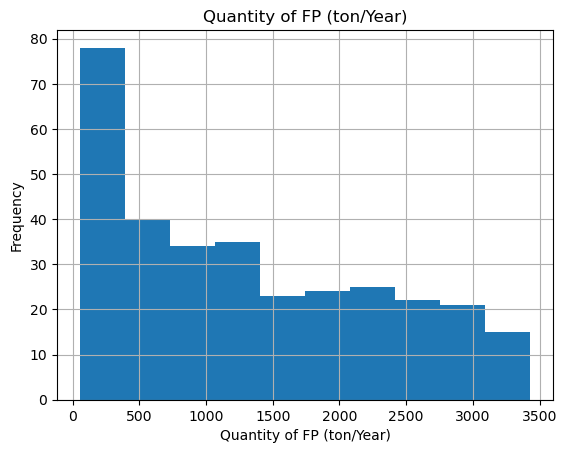

In [151]:
col = df.columns[3]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Food Report/fourth_column_hist.png')

plt.show()

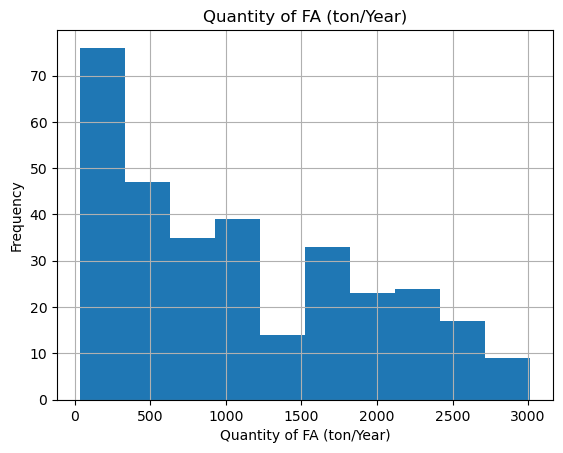

In [152]:
col = df.columns[4]

# Plot
plt.figure()
df[col].hist()

plt.title(col)
plt.xlabel(col)
plt.ylabel('Frequency')

# Save the figure
plt.savefig('Desktop/Food Report/fifth_column_hist.png')

plt.show()

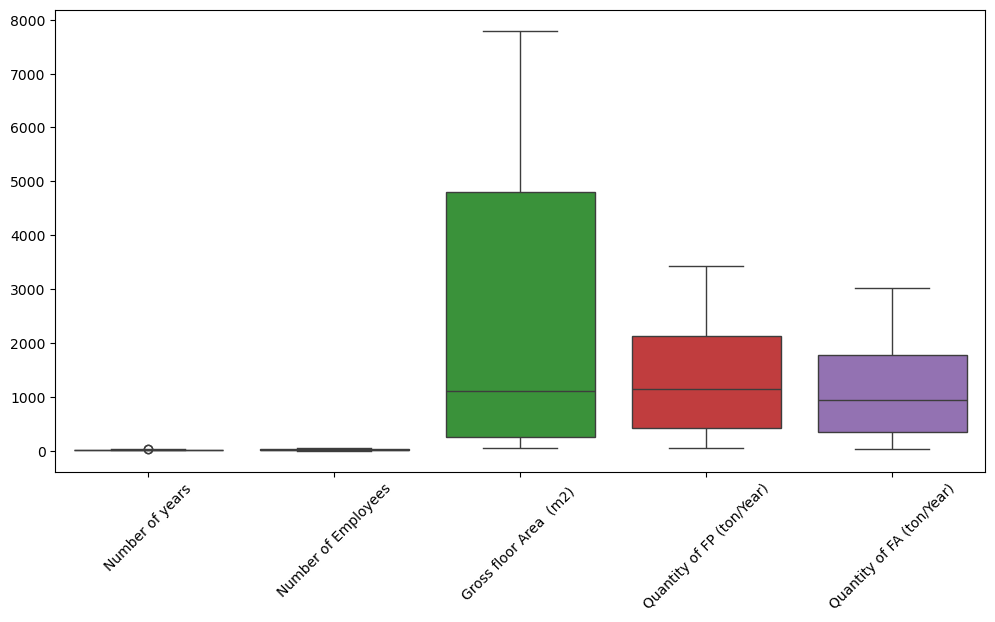

In [154]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
# Save the figure
plt.savefig('Desktop/Food Report/Distrbution,Variability,outlier_column_hist.png')
plt.show()

In [156]:
df1 = df.drop(columns=[ 'Quantity of FA (ton/Year)'])

In [158]:
df2 = df.drop(columns=[ 'Quantity of FP (ton/Year)'])

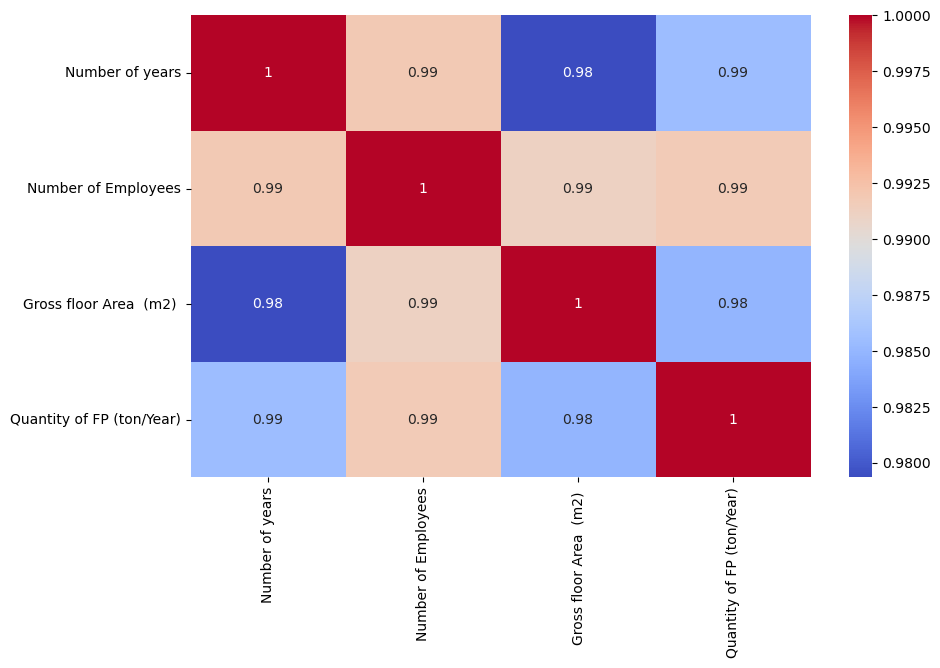

In [159]:
corr = df1.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig('Desktop/Food Report/FP_Corr.png')

plt.show()

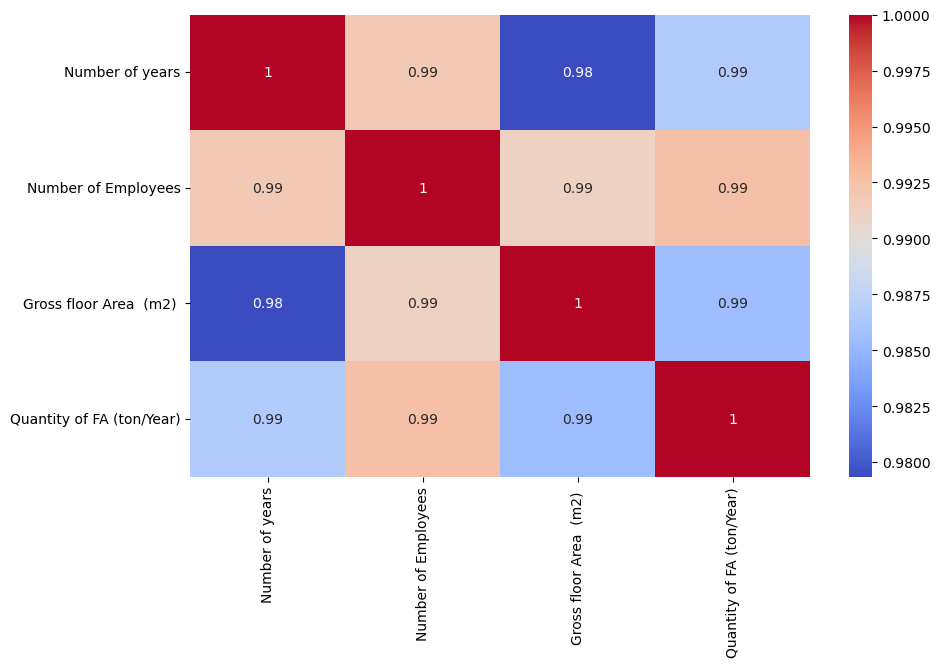

In [160]:
corr = df2.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig('Desktop/Food Report/FA_Corr.png')

plt.show()

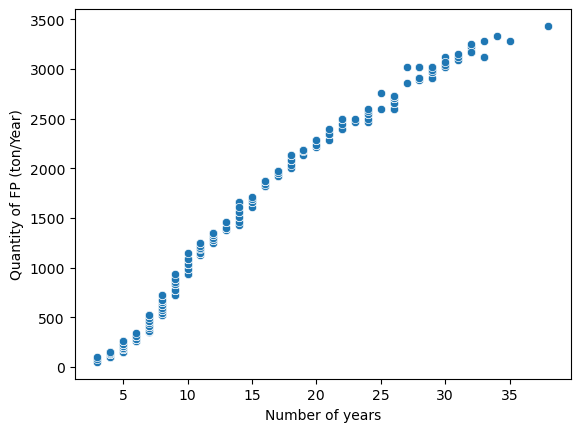

In [161]:
sns.scatterplot(x='Number of years', y='Quantity of FP (ton/Year)', data=df1)
# Save the figure
plt.savefig('Desktop/Food Report/FPvsNo.years_column_hist.png')

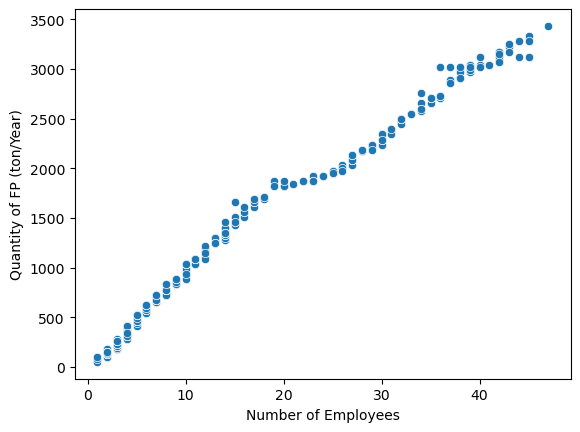

In [162]:
sns.scatterplot(x='Number of Employees', y='Quantity of FP (ton/Year)', data=df1)
# Save the figure
plt.savefig('Desktop/Food Report/FPvsNo.Employees_column_hist.png')

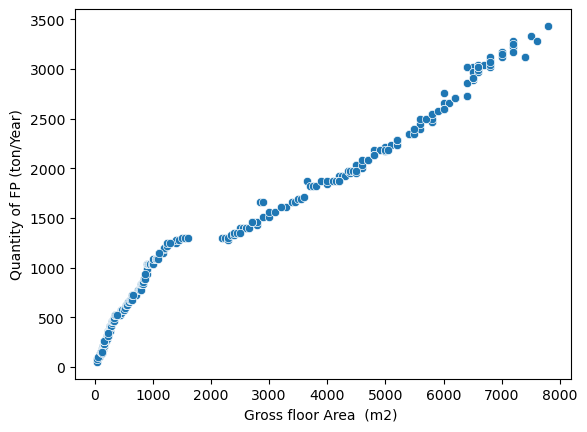

In [166]:
sns.scatterplot(x='Gross floor Area  (m2) ', y='Quantity of FP (ton/Year)', data=df1)
# Save the figure
plt.savefig('Desktop/Food Report/FPvsNo.GFA_column_hist.png')

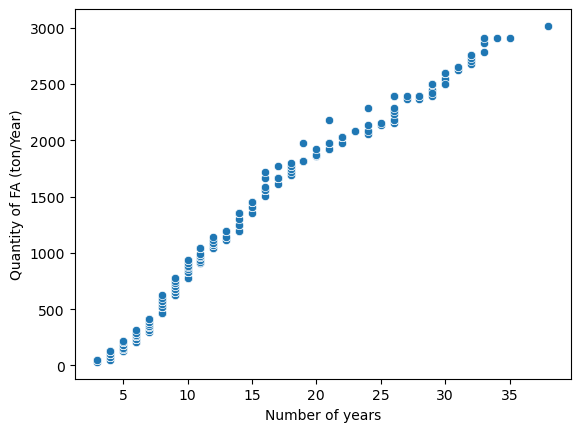

In [167]:
sns.scatterplot(x='Number of years', y='Quantity of FA (ton/Year)', data=df2)
# Save the figure
plt.savefig('Desktop/Food Report/FAvsNo.years_column_hist.png')

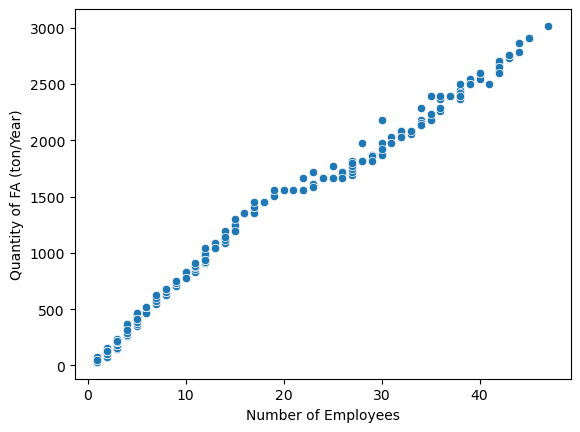

In [169]:
sns.scatterplot(x='Number of Employees', y='Quantity of FA (ton/Year)', data=df2)
# Save the figure
plt.savefig('Desktop/Food Report/FAvsNo.Employees_column_hist.png')

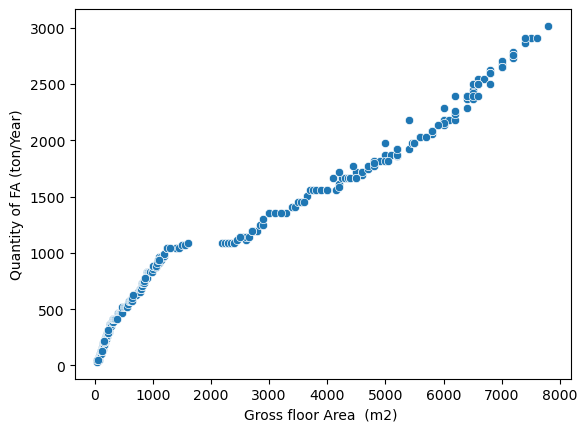

In [174]:
sns.scatterplot(x='Gross floor Area  (m2) ', y='Quantity of FA (ton/Year)', data=df2)
# Save the figure
plt.savefig('Desktop/Food Report/FAvsNo.GFA_column_hist.png')

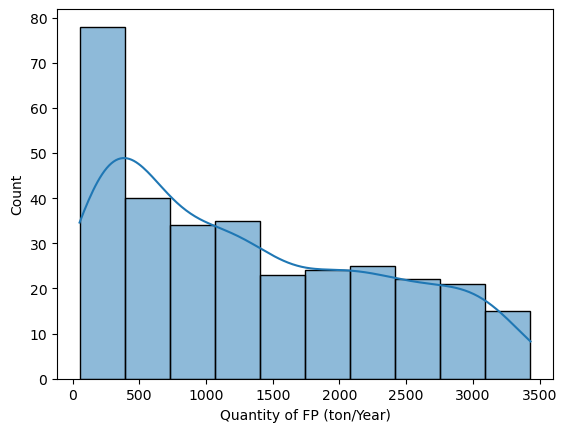

In [178]:
sns.histplot(df1['Quantity of FP (ton/Year)'], kde=True)
# Save the figure
plt.savefig('Desktop/Food Report/FPvsCount_column_hist.png')

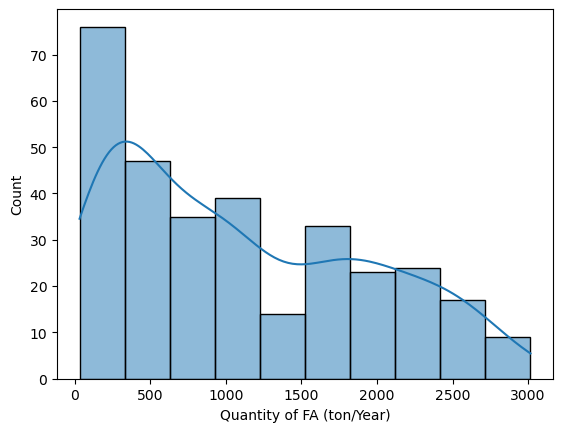

In [180]:
sns.histplot(df2['Quantity of FA (ton/Year)'], kde=True)
# Save the figure
plt.savefig('Desktop/Food Report/FAvsCount_column_hist.png')

In [182]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Number of years            317 non-null    int64
 1   Number of Employees        317 non-null    int64
 2   Gross floor Area  (m2)     317 non-null    int64
 3   Quantity of FP (ton/Year)  317 non-null    int64
dtypes: int64(4)
memory usage: 10.0 KB


In [184]:
X = df1.drop(columns=['Quantity of FP (ton/Year)'])
y = df1['Quantity of FP (ton/Year)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [186]:
X_train.shape

(253, 3)

In [188]:
X_test.shape

(64, 3)

In [190]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 253 entries, 209 to 102
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Number of years          253 non-null    int64
 1   Number of Employees      253 non-null    int64
 2   Gross floor Area  (m2)   253 non-null    int64
dtypes: int64(3)
memory usage: 7.9 KB


In [192]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

In [194]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))
print("R2:", r2_score(y_test, y_pred_lr))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

# ✅ Full regression summary
print("\nOLS Regression Summary:")
print(ols_model.summary())

MAE: 112.75669626325484
RMSE: 134.32688264018682
R2: 0.9824179512874652
Intercept: 94.72448478095976

Coefficients with P-values and Significance Level:
Number of years: Coef = 19.701, P-value = 0.010, Significance ≈ 99.0%
Number of Employees: Coef = 52.670, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.050, P-value = 0.039, Significance ≈ 96.1%

OLS Regression Summary:
                                OLS Regression Results                               
Dep. Variable:     Quantity of FP (ton/Year)   R-squared:                       0.984
Model:                                   OLS   Adj. R-squared:                  0.984
Method:                        Least Squares   F-statistic:                     5229.
Date:                       Sun, 05 Jul 2026   Prob (F-statistic):          1.68e-224
Time:                               18:05:14   Log-Likelihood:                -1573.3
No. Observations:                        253   AIC:                             3155.


C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2797349557.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2797349557.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2797349557.py:14: FutureWarn

In [74]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [76]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))
print("R2:", r2_score(y_test, y_pred_rf))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

MAE: 24.553271278634597
RMSE: 38.46082247898381
R2: 0.9985586125331557
Intercept: 94.72448478095976

Coefficients with P-values and Significance Level:
Number of years: Coef = 19.701, P-value = 0.010, Significance ≈ 99.0%
Number of Employees: Coef = 52.670, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.050, P-value = 0.039, Significance ≈ 96.1%


C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\990907770.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\990907770.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\990907770.py:14: FutureWarning

In [78]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [80]:
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", mean_squared_error(y_test, y_pred_gb, squared=False))
print("R2:", r2_score(y_test, y_pred_gb))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

MAE: 24.126327450063492
RMSE: 41.6075378140258
R2: 0.9983131065966289
Intercept: 94.72448478095976

Coefficients with P-values and Significance Level:
Number of years: Coef = 19.701, P-value = 0.010, Significance ≈ 99.0%
Number of Employees: Coef = 52.670, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.050, P-value = 0.039, Significance ≈ 96.1%


C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\3593990410.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\3593990410.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\3593990410.py:14: FutureWarn

In [82]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [84]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y_test, y_pred_xgb, squared=False))
print("R2:", r2_score(y_test, y_pred_xgb))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

MAE: 25.501251220703125
RMSE: 45.510726707681634
R2: 0.9979817677230903
Intercept: 94.72448478095976

Coefficients with P-values and Significance Level:
Number of years: Coef = 19.701, P-value = 0.010, Significance ≈ 99.0%
Number of Employees: Coef = 52.670, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.050, P-value = 0.039, Significance ≈ 96.1%


C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2046622440.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2046622440.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2046622440.py:14: FutureWarn

In [86]:
err_lr = y_test - y_pred_lr
err_gb = y_test - y_pred_gb
err_rf = y_test - y_pred_rf
err_xgb = y_test - y_pred_xgb

In [88]:
stat, p_value = ttest_rel(abs(err_xgb), abs(err_lr))
print("p-value:", p_value)

p-value: 4.022673136655198e-15


In [90]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number of years            317 non-null    int64  
 1   Number of Employees        317 non-null    int64  
 2   Gross floor Area  (m2)     317 non-null    int64  
 3   Quantity of FA (ton/Year)  317 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 10.0 KB


In [198]:
X = df2.drop(columns=['Quantity of FA (ton/Year)'])
y = df2['Quantity of FA (ton/Year)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [200]:
X_train.shape

(253, 3)

In [202]:
X_test.shape

(64, 3)

In [204]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 253 entries, 209 to 102
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Number of years          253 non-null    int64
 1   Number of Employees      253 non-null    int64
 2   Gross floor Area  (m2)   253 non-null    int64
dtypes: int64(3)
memory usage: 7.9 KB


In [206]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

In [208]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))
print("R2:", r2_score(y_test, y_pred_lr))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

# ✅ Full regression summary
print("\nOLS Regression Summary:")
print(ols_model.summary())

MAE: 81.9396619070618
RMSE: 97.0717499745616
R2: 0.9876196658662664
Intercept: 91.34130644809272

Coefficients with P-values and Significance Level:
Number of years: Coef = 13.174, P-value = 0.035, Significance ≈ 96.5%
Number of Employees: Coef = 46.123, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.042, P-value = 0.032, Significance ≈ 96.8%

OLS Regression Summary:
                                OLS Regression Results                               
Dep. Variable:     Quantity of FA (ton/Year)   R-squared:                       0.985
Model:                                   OLS   Adj. R-squared:                  0.985
Method:                        Least Squares   F-statistic:                     5513.
Date:                       Sun, 05 Jul 2026   Prob (F-statistic):          2.60e-227
Time:                               18:07:14   Log-Likelihood:                -1521.8
No. Observations:                        253   AIC:                             3052.
Df R

C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2797349557.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2797349557.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2797349557.py:14: FutureWarn

In [106]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [108]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))
print("R2:", r2_score(y_test, y_pred_rf))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

MAE: 28.02680213406381
RMSE: 47.63515030220629
R2: 0.9970187271311269
Intercept: 91.34130644809272

Coefficients with P-values and Significance Level:
Number of years: Coef = 13.174, P-value = 0.035, Significance ≈ 96.5%
Number of Employees: Coef = 46.123, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.042, P-value = 0.032, Significance ≈ 96.8%


C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\990907770.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\990907770.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\990907770.py:14: FutureWarning

In [110]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [112]:
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", mean_squared_error(y_test, y_pred_gb, squared=False))
print("R2:", r2_score(y_test, y_pred_gb))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

MAE: 27.455785994145465
RMSE: 49.882369540005364
R2: 0.9967308052046595
Intercept: 91.34130644809272

Coefficients with P-values and Significance Level:
Number of years: Coef = 13.174, P-value = 0.035, Significance ≈ 96.5%
Number of Employees: Coef = 46.123, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.042, P-value = 0.032, Significance ≈ 96.8%


C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\3593990410.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\3593990410.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\3593990410.py:14: FutureWarn

In [114]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [116]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y_test, y_pred_xgb, squared=False))
print("R2:", r2_score(y_test, y_pred_xgb))
print("Intercept:", model.intercept_)
# --- statsmodels for p-values ---
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Feature names
feature_names = ["Number of years", "Number of Employees", "Gross floor Area (m2)"]

print("\nCoefficients with P-values and Significance Level:")
for i, name in enumerate(feature_names):
    coef = ols_model.params[i+1]
    pval = ols_model.pvalues[i+1]
    
    # Convert to significance level in percentage
    significance_percent = (1 - pval) * 100
    
    print(f"{name}: Coef = {coef:.3f}, P-value = {pval:.3f}, Significance ≈ {significance_percent:.1f}%")

MAE: 32.28929504752159
RMSE: 61.0072921745437
R2: 0.9951099855065076
Intercept: 91.34130644809272

Coefficients with P-values and Significance Level:
Number of years: Coef = 13.174, P-value = 0.035, Significance ≈ 96.5%
Number of Employees: Coef = 46.123, P-value = 0.000, Significance ≈ 100.0%
Gross floor Area (m2): Coef = 0.042, P-value = 0.032, Significance ≈ 96.8%


C:\Users\Hena\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2046622440.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = ols_model.params[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2046622440.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = ols_model.pvalues[i+1]
C:\Users\Hena\AppData\Local\Temp\ipykernel_15576\2046622440.py:14: FutureWarn

In [118]:
err_lr = y_test - y_pred_lr
err_gb = y_test - y_pred_gb
err_rf = y_test - y_pred_rf
err_xgb = y_test - y_pred_xgb

In [120]:
stat, p_value = ttest_rel(abs(err_gb), abs(err_lr))
print("p-value:", p_value)

p-value: 2.8207232328080407e-07


In [122]:
stat, p_value = ttest_rel(abs(err_gb), abs(err_rf))
print("p-value:", p_value)

p-value: 0.7046339196508389


In [124]:
stat, p_value = ttest_rel(abs(err_lr), abs(err_rf))
print("p-value:", p_value)

p-value: 2.344834652822527e-07
